# Проект: Многослойный персептрон
## EDA — первичный анализ данных
Датасет: Breast Cancer Wisconsin Diagnostic (WDBC). 569 объектов, 30 признаков ядер клеток,
метка `diagnosis`: M (malignant / злокачественная) или B (benign / доброкачественная).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_cols = ["mean radius","mean texture","mean perimeter","mean area","mean smoothness",
             "mean compactness","mean concavity","mean concave points","mean symmetry",
             "mean fractal dimension"]
se_cols   = [f"{n} error" for n in ["radius","texture","perimeter","area","smoothness",
             "compactness","concavity","concave points","symmetry","fractal dimension"]]
worst_cols= ["worst radius","worst texture","worst perimeter","worst area","worst smoothness",
             "worst compactness","worst concavity","worst concave points","worst symmetry",
             "worst fractal dimension"]

header = ["id", "diagnosis"] + mean_cols + se_cols + worst_cols

df = pd.read_csv("data.csv", header=None, names=header)

print("Форма:", df.shape)
df.head()

Форма: (569, 32)


,id,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Проверка качества данных
print("Пропусков в данных:", df.isna().sum().sum())
print("Полностью дублирующихся строк:", df.duplicated().sum())
print("Дублирующихся id:", df["id"].duplicated().sum())
print()
print("Типы данных:")
print(df.dtypes.value_counts())

Пропусков в данных: 0
Полностью дублирующихся строк: 0
Дублирующихся id: 0

Типы данных:
float64    30
int64       1
object      1
Name: count, dtype: int64


diagnosis
B    357
M    212
Name: count, dtype: int64

B (доброкачественные): 357 объектов (62.7%)
M (злокачественные):   212 объектов (37.3%)


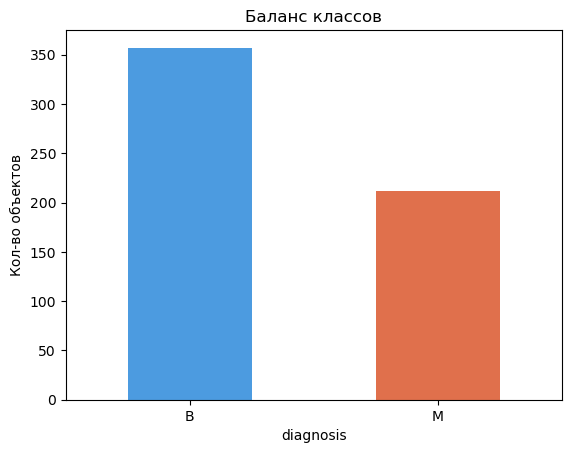

In [8]:
counts = df["diagnosis"].value_counts()
print(counts)
print()
print(f"B (доброкачественные): {counts['B']} объектов ({counts['B']/len(df)*100:.1f}%)")
print(f"M (злокачественные):   {counts['M']} объектов ({counts['M']/len(df)*100:.1f}%)")

counts.plot.bar(rot=0, color=["#4c9be0", "#e0704c"],
                title="Баланс классов", ylabel="Кол-во объектов")
plt.show()

In [9]:
# Описательная статистика
X = df.drop(columns=["id", "diagnosis"])
desc = X.describe().T[["mean", "std", "min", "50%", "max"]]
desc.columns = ["mean", "std", "min", "median", "max"]
desc.round(3)

,mean,std,min,median,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


In [10]:
rng = desc["max"] - desc["min"]
print("Признаки с наибольшим разбросом:")
print(rng.sort_values(ascending=False).head(3).round(1))
print("\nПризнаки с наименьшим разбросом:")
print(rng.sort_values().head(3).round(4))

Признаки с наибольшим разбросом:
worst area    4068.8
mean area     2357.5
area error     535.4
dtype: float64

Признаки с наименьшим разбросом:
fractal dimension error    0.0289
smoothness error           0.0294
mean fractal dimension     0.0475
dtype: float64


In [11]:
key = ["mean radius", "mean area", "mean concave points", "worst perimeter", "worst concave points"]
df.groupby("diagnosis")[key].mean().T.round(3)

diagnosis,B,M
mean radius,12.147,17.463
mean area,462.790,978.376
mean concave points,0.026,0.088
worst perimeter,87.006,141.370
worst concave points,0.074,0.182


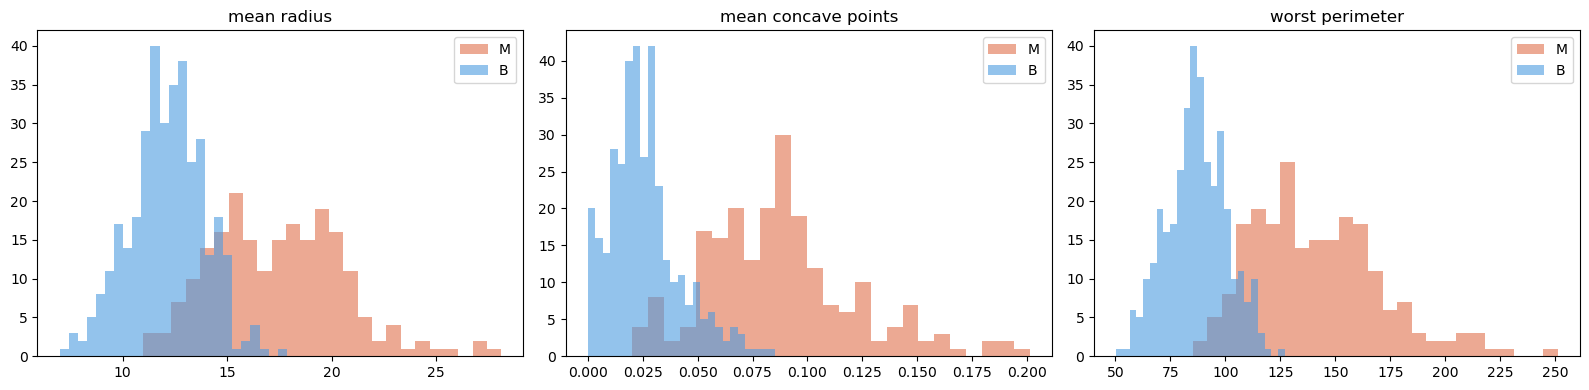

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, feat in zip(ax, ["mean radius", "mean concave points", "worst perimeter"]):
    for lab, c in [("M", "#e0704c"), ("B", "#4c9be0")]:
        a.hist(df.loc[df.diagnosis == lab, feat], bins=25, alpha=0.6, label=lab, color=c)
    a.set_title(feat)
    a.legend()
plt.tight_layout()
plt.show()

In [13]:
y = (df["diagnosis"] == "M").astype(int)
corr_target = X.apply(lambda c: np.corrcoef(c, y)[0, 1])
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
print(corr_target.head(8).round(3))

worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
dtype: float64


In [14]:
corr = X.corr()
high = corr.where(np.triu(np.ones_like(corr, bool), k=1)).stack()
print("Пар с |r| > 0.95:", int((high.abs() > 0.95).sum()), "из", len(high))
print()
print(high.abs().sort_values(ascending=False).head(5).round(3))

Пар с |r| > 0.95: 15 из 435

mean radius     mean perimeter     0.998
worst radius    worst perimeter    0.994
mean radius     mean area          0.987
mean perimeter  mean area          0.987
worst radius    worst area         0.984
dtype: float64


C:\Users\Amir Sagdullin\AppData\Local\Temp\ipykernel_8560\3571175475.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["B", "M"], patch_artist=True,
C:\Users\Amir Sagdullin\AppData\Local\Temp\ipykernel_8560\3571175475.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["B", "M"], patch_artist=True,
C:\Users\Amir Sagdullin\AppData\Local\Temp\ipykernel_8560\3571175475.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["B", "M"], patch_artist=True,
C:\Users\Amir Sagdullin\AppData\Local\Temp\ipykernel_8560\3571175475.py:6: MatplotlibDeprecationW

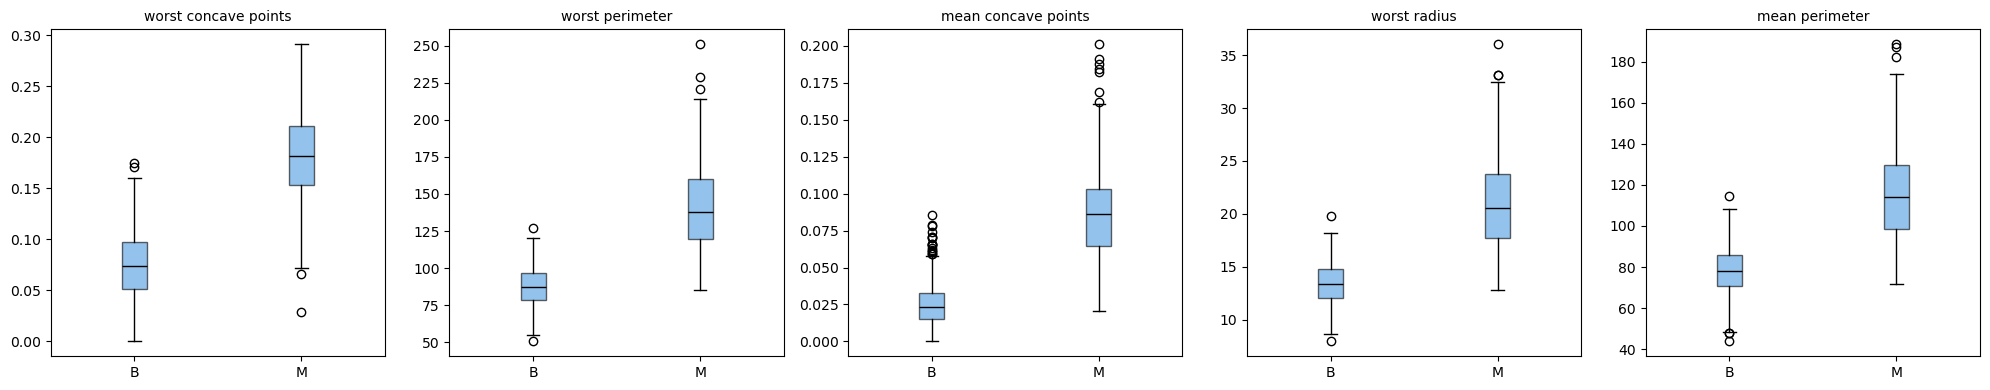

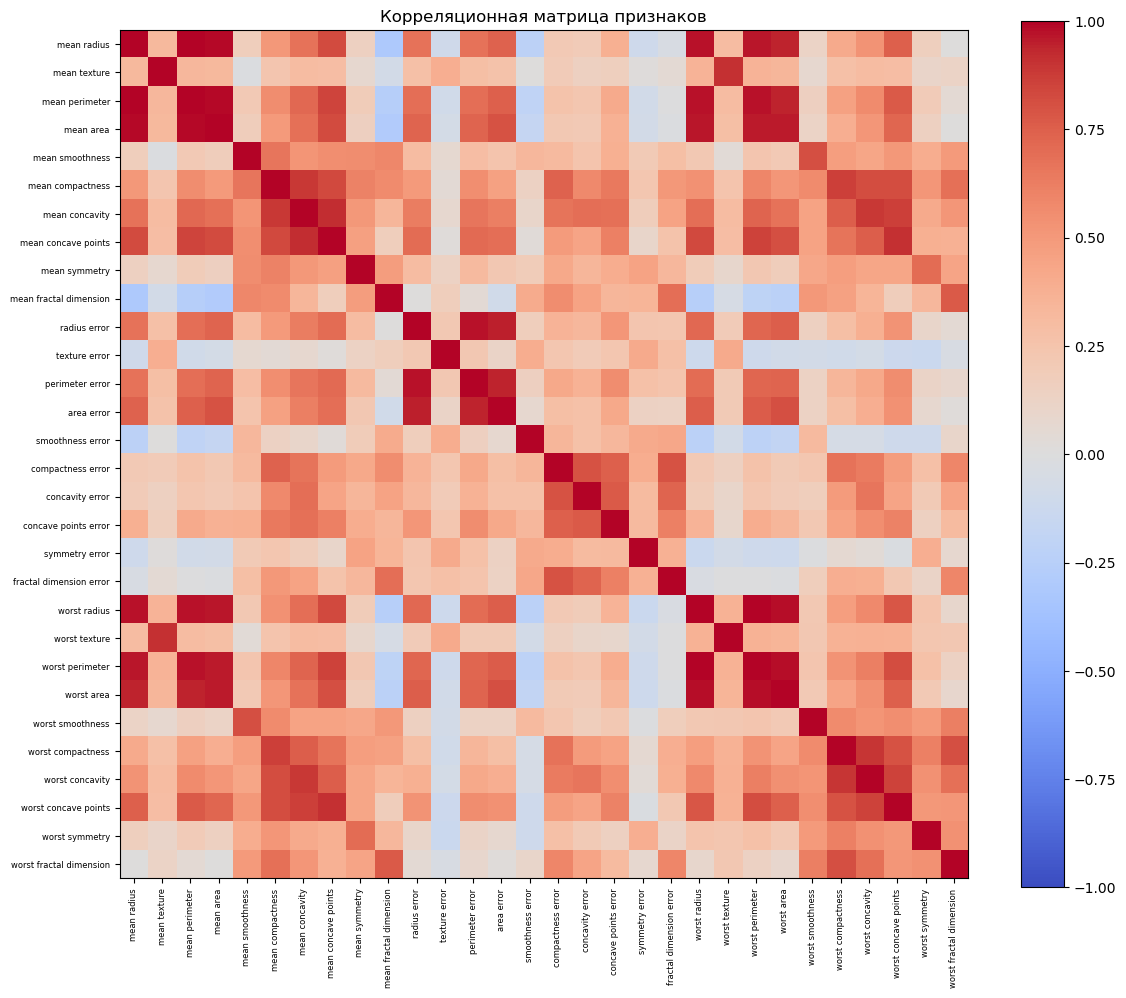

Топ-10 признаков по доле выбросов (%):
area error                 11.42
radius error                6.68
perimeter error             6.68
worst area                  6.15
smoothness error            5.27
fractal dimension error     4.92
compactness error           4.92
symmetry error              4.75
mean area                   4.39
worst fractal dimension     4.22
dtype: float64


In [15]:
top5 = corr_target.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5):
    data = [df.loc[df.diagnosis == "B", feat], df.loc[df.diagnosis == "M", feat]]
    ax.boxplot(data, labels=["B", "M"], patch_artist=True,
               boxprops=dict(facecolor="#4c9be0", alpha=0.6),
               medianprops=dict(color="black"))
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(X.corr(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(X.columns))); ax.set_xticklabels(X.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(X.columns))); ax.set_yticklabels(X.columns, fontsize=6)
plt.colorbar(im)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

def outlier_share(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100

out = X.apply(outlier_share).sort_values(ascending=False)
print("Топ-10 признаков по доле выбросов (%):")
print(out.head(10).round(2))

## Выводы EDA
1. Данные чистые: пропусков нет, типы корректные (30 вещественных признаков).
2. Классы умеренно несбалансированы: B 62.7% / M 37.3% — приемлемо, oversampling не требуется.
3. Масштабы признаков различаются на порядки -> необходима стандартизация (z-score).
4. Признаки radius/perimeter/area сильно коррелируют (r > 0.98) — геометрически связаны.
5. Самые информативные признаки: concave points, perimeter, radius (mean и worst), r ≈ 0.73–0.79.